In [1]:
import numpy as np
from astropy import units as u
from astropy.constants import m_e, h

from agnpy.spectra import PowerLaw
from agnpy.emission_regions import Blob
from agnpy.synchrotron import Synchrotron
from agnpy.time_evolution.time_evolution import synchrotron_loss
from agnpy.utils.plot import plot_sed
from agnpy.time_evolution.liv import LIVdelay

import matplotlib.pyplot as plt

In [2]:
# set the quantities defining the blob and the electron distribution
R_b = 1e16 * u.cm
V_b = 4 / 3 * np.pi * R_b ** 3
W_e = 1e48 * u.erg # total energy in electrons

# initial electron distribution
n_e_initial = PowerLaw.from_total_energy(
    W_e,
    V_b,
    p=2.8,
    gamma_min=1e2,
    gamma_max=1e7,
    mass=m_e,
)

In [3]:
# define the blob and the energy loss mechanism
blob = Blob(n_e=n_e_initial)
synch = Synchrotron(blob)


# define the blob and the energy loss mechanism for LIV
blob_liv = Blob(n_e=n_e_initial)
synch_liv = Synchrotron(blob_liv)

# define LIVdelay classes
nu_syn = np.logspace(8, 23) * u.Hz
reference_0liv = LIVdelay(lambda_liv=0*u.s/u.TeV, n_liv=1, blob=blob, nu_syn=nu_syn, synch=synch, time_step=10*u.min, steps=6)
with_liv = LIVdelay(lambda_liv=200*u.s/u.TeV, n_liv=1, blob=blob_liv, nu_syn=nu_syn, synch=synch_liv, time_step=10*u.min, steps=6)

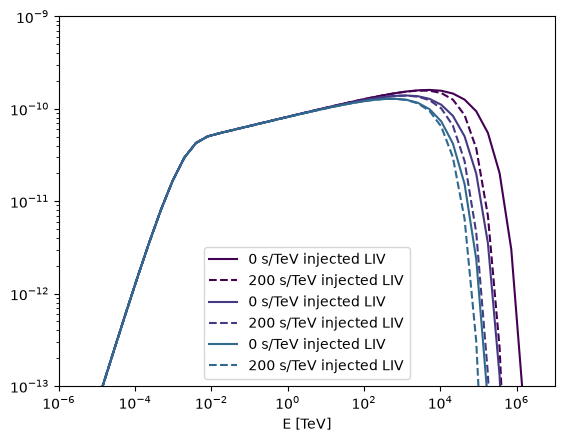

In [5]:
cmap = plt.get_cmap('viridis')
for i in range(3):
    plt.plot(
        nu_syn*h.to("eV s"),
        reference_0liv.evaluate(i*10*u.min),
        label=r"0 s/TeV injected LIV",
        color=cmap(i / 6)
    )
    plt.plot(
        nu_syn*h.to("eV s"),
        with_liv.evaluate(i*10*u.min),
        '--',
        label=r"200 s/TeV injected LIV",
        color=cmap(i / 6)
    )

plt.xscale('log')
plt.xlabel('E [TeV]')
plt.xlim([1e-6, 1e7])
plt.yscale('log')
plt.ylim([1e-13, 1e-9])
plt.legend()
plt.show()